# Imports & Setup

In [1]:
import jax.numpy as jnp
from jaxtyping import Array, Float

from tqdm.notebook import tqdm
import pandas as pd
from pyprojroot import here

from isssm.importance_sampling import ess_pct

import tensorflow_probability.substrates.jax.distributions as tfd
from tensorflow_probability.substrates.jax.distributions import (
    MixtureSameFamily,
    Normal,
    Categorical,
)

import jax.random as jrn
import matplotlib.pyplot as plt
from jax import vmap
from functools import partial

key = jrn.PRNGKey(2342341234)

We'll define the targets $\mathbf P$ for both examples:

* Normal: $\mathcal N (0, 1)$,
* Gaussian location mixure (GMM): $ \frac{1}{2} \left( \mathcal N(-1, \omega^{2}) + \mathcal N(1, \omega^{2})\right)$ for $\omega^{2} \in \{0.1, 0.5, 1.0\}$ and
* Gaussain scale mixture (GGM_scale): $  \frac{1}{2} \left( \mathcal N(0, 1) + \mathcal N(0, \varepsilon^{-2})\right)$ for $\varepsilon^{2} \in \{2, 10, 100\}$.

In [2]:
tau2 = 1.0
N_interpolate = 101

N_samples = int(1e4)
N_var = int(1e4)
N_boot = int(1e3)


s2s = jnp.linspace(0.5 * tau2, 3.0 * tau2, N_interpolate)
mus = jnp.linspace(0.0, 2.0, N_interpolate)

omega2s = jnp.array([0.1, 0.5, 1.0])
eps2s = 1 / jnp.array([0.01, 0.1, 0.5])

In [3]:
def gmm_location(omega2: float):
    P = MixtureSameFamily(
        mixture_distribution=Categorical(probs=jnp.array([0.5, 0.5])),
        components_distribution=Normal(jnp.array([-1.0, 1.0]), jnp.sqrt(omega2)),
    )
    return P


def gmm_scale(eps2: float):
    P = MixtureSameFamily(
        mixture_distribution=Categorical(probs=jnp.array([0.5, 0.5])),
        components_distribution=Normal(
            jnp.array([0.0, 0.0]), jnp.array([1.0, 1 / jnp.sqrt(eps2)])
        ),
    )
    return P


targets = {
    "Normal": Normal(loc=0.0, scale=1.0),
    **{f"GMM_location_{omega2:.2f}": gmm_location(omega2) for omega2 in omega2s},
    **{f"GMM_scale_{eps2:.2f}": gmm_scale(eps2) for eps2 in eps2s},
}

In [ ]:
target_meta = pd.DataFrame(
    [
        pd.Series({"P": "Normal", "param_name": None, "param_value": None}),
        *[
            pd.Series(
                {
                    "P": f"GMM_location_{omega2:.2f}",
                    "param_name": "$\\omega^2$",
                    "param_value": omega2,
                }
            )
            for omega2 in omega2s
        ],
        *[
            pd.Series(
                {
                    "P": f"GMM_scale_{eps2:.2f}",
                    "param_name": "$\\varepsilon^2$",
                    "param_value": eps2,
                }
            )
            for eps2 in eps2s
        ],
    ]
)

target_meta.to_csv(here("data/figures/fixed_mu_s2_target_meta.csv"), index=False)

# Univariate Gaussian proposal, $\sigma^2$ fixed
## Asymptotic variances by simulation

To assess simulation error, we will estimate standard errors by bootstrap, for which we use our own implementation, based on resampling.

In [5]:
def bootstrap_se(samples: Float[Array, "N ..."], fun, key, N_boot: int):
    """Simple bootstrap standard error estimation."""
    N, *_ = samples.shape
    key, sk = jrn.split(key)
    resamples = jrn.choice(sk, samples, shape=(N_boot, N), replace=True)
    boot_estimates = vmap(fun)(resamples)
    return jnp.std(boot_estimates, axis=0)

To estimate $\mu$ in 3.55, we implement both the CE method and EIS.

In [6]:
def ce_mu(samples: Float[Array, "N"], weights: Float[Array, "N"], s2: float):
    mu = jnp.sum(samples * weights) / jnp.sum(weights)
    psi = mu / jnp.sqrt(s2)
    return psi


def eis_mu(samples, weights, logp, s2):
    (N,) = weights.shape
    X = jnp.array([jnp.ones(N), samples / jnp.sqrt(s2)]).reshape((2, N)).T

    wX = jnp.einsum("i,ij->ij", jnp.sqrt(weights), X)
    logh = Normal(0, jnp.sqrt(s2)).log_prob(samples)
    y = jnp.sqrt(weights) * (logp - logh)
    beta = jnp.linalg.solve(wX.T @ wX, wX.T @ y)

    psi = beta[1]
    return psi

For any given target $\mathbf P$ and $\sigma^2$, we estimate the asymptotic variance of both methods by simulation. We also estimate the variance ratio as well as standard errors for all estimates by the bootstrap. 

Note that we convert from the parameter $\mu$ to $\psi = \frac{\mu}{\sigma}$, as it is the natural parameter we estimate with both methods (this doesn't affect the variance ratio, but does affect the individual variances).

In [7]:
def compare_ce_eis_fixed_s2(
    target: str, s2: float, N_samples: int, N_var: int, N_boot: int, key
):
    P = targets[target]

    tau2 = P.variance()

    mu_ce = 0.0
    mu_eis = 0.0

    key, subkey = jrn.split(key)
    samples = P.sample((N_var, N_samples), seed=subkey)
    weights = jnp.ones_like(samples)

    logp = P.log_prob(samples)

    # CE-method
    psis_ce = vmap(partial(ce_mu, s2=s2))(samples, weights)
    var_ce = N_samples * jnp.var(psis_ce)
    key, sk_boot = jrn.split(key)
    se_ce = bootstrap_se(psis_ce, jnp.var, sk_boot, N_boot)

    # EIS
    psis_eis = vmap(partial(eis_mu, s2=s2))(samples, weights, logp)
    var_eis = N_samples * jnp.var(psis_eis)
    se_eis = bootstrap_se(psis_eis, jnp.var, sk_boot, N_boot)

    # var_ratio
    var_ratio = var_eis / var_ce
    se_var_ratio = bootstrap_se(
        jnp.stack([psis_ce, psis_eis], axis=1),
        lambda x: jnp.var(x[:, 1]) / jnp.var(x[:, 0]),
        sk_boot,
        N_boot,
    )

    # efficiency factor
    optimal_G = Normal(0, jnp.sqrt(s2))

    key, subkey = jrn.split(key)
    samples_ef = optimal_G.sample((N_samples), seed=subkey)
    log_weights_ef = P.log_prob(samples_ef) - optimal_G.log_prob(samples_ef)

    EF = ess_pct(log_weights_ef)

    return pd.Series(
        {
            "P": target,
            "tau2": tau2,
            "s2": s2,
            "mu_ce": mu_ce,
            "var_ce": var_ce,
            "se_ce": se_ce,
            "ef_ce": EF,
            "mu_eis": mu_eis,
            "var_eis": var_eis,
            "se_eis": se_eis,
            "ef_eis": EF,
            "var_ratio": var_ratio,
            "se_var_ratio": se_var_ratio,
        }
    )

In [8]:
key, sk = jrn.split(key)
result_fixed_s2 = []

for target in tqdm(targets.keys()):
    for s2 in tqdm(s2s):
        result_fixed_s2.append(
            compare_ce_eis_fixed_s2(target, s2, N_samples, N_var, N_boot, sk)
        )
result_fixed_s2 = pd.DataFrame(result_fixed_s2)

  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/101 [00:00<?, ?it/s]

  0%|          | 0/101 [00:00<?, ?it/s]

  0%|          | 0/101 [00:00<?, ?it/s]

  0%|          | 0/101 [00:00<?, ?it/s]

  0%|          | 0/101 [00:00<?, ?it/s]

  0%|          | 0/101 [00:00<?, ?it/s]

  0%|          | 0/101 [00:00<?, ?it/s]

In [9]:
result_fixed_s2.to_csv(here("data/figures/fixed_s2.csv"), index=False)

## Compare to analytical results

To verify the simulation results, we compare to the analytical expression of the variance ratio derived in the thesis.

In [ ]:
def var_ratio_normal_analytical(s2, tau2):
    a = 1 / 2 * (1 / s2 - 1 / tau2)
    gamma = 10 * a**2 * tau2**3
    var_eis_true = s2 / tau2**2 * gamma
    var_ce_true = tau2 / s2
    return var_eis_true / var_ce_true

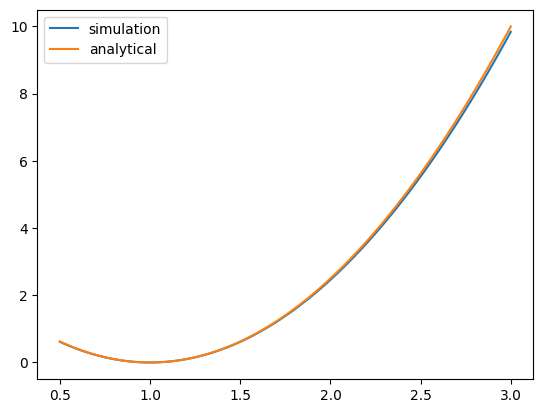

In [11]:
normal_result = result_fixed_s2[result_fixed_s2["P"] == "Normal"]

true_ratios = var_ratio_normal_analytical(normal_result["s2"], normal_result["tau2"])
plt.plot(normal_result["s2"], normal_result["var_ratio"], label="simulation")
plt.plot(normal_result["s2"], true_ratios, label="analytical")
plt.legend()
plt.show()

# Univariate Gaussian proposal, $\mu$ fixed

## Asymptotic variances by simulation

In [12]:
def ce_s2(samples, weights, mu):
    s2 = jnp.sum((samples - mu) ** 2 * weights) / jnp.sum(weights)
    psi = -1 / 2 / s2
    return psi


def eis_s2(samples, weights, logp, mu):
    (N,) = weights.shape
    X = jnp.array([jnp.ones(N), (samples - mu) ** 2]).T

    wX = jnp.einsum("i,ij->ij", jnp.sqrt(weights), X)
    y = jnp.sqrt(weights) * logp
    beta = jnp.linalg.solve(wX.T @ wX, wX.T @ y)

    psi = beta[2]
    return psi

In [13]:
def compare_ce_eis_fixed_mu(
    target: str, mu: float, N_samples: int, N_var: int, N_boot: int, key
):
    P = targets[target]

    tau2 = P.variance()

    key, subkey = jrn.split(key)
    samples = P.sample((N_var, N_samples), seed=subkey)
    weights = jnp.ones_like(samples)

    logp = P.log_prob(samples)

    # CE-method
    psis_ce = vmap(partial(ce_s2, mu=mu))(samples, weights)
    s2_ce = jnp.mean(-1 / 2 / psis_ce)

    var_ce = N_samples * jnp.var(psis_ce)
    key, sk_boot = jrn.split(key)
    se_ce = bootstrap_se(psis_ce, jnp.var, sk_boot, N_boot)

    # EIS
    psis_eis = vmap(partial(eis_s2, mu=mu))(samples, weights, logp)
    s2_eis = jnp.mean(-1 / 2 / psis_eis)

    var_eis = N_samples * jnp.var(psis_eis)
    se_eis = bootstrap_se(psis_eis, jnp.var, sk_boot, N_boot)

    # var_ratio
    var_ratio = var_eis / var_ce
    se_var_ratio = bootstrap_se(
        jnp.stack([psis_ce, psis_eis], axis=1),
        lambda x: jnp.var(x[:, 1]) / jnp.var(x[:, 0]),
        sk_boot,
        N_boot,
    )

    # efficiency factor
    key, subkey = jrn.split(key)

    optimal_G_ce = Normal(mu, jnp.sqrt(s2_ce))
    samples_ef_ce = optimal_G_ce.sample((N_samples), seed=subkey)
    log_weights_ef_ce = P.log_prob(samples_ef_ce) - optimal_G_ce.log_prob(samples_ef_ce)
    EF_ce = ess_pct(log_weights_ef_ce)

    optimal_G_eis = Normal(mu, jnp.sqrt(s2_eis))
    samples_ef_eis = optimal_G_eis.sample((N_samples), seed=subkey)
    log_weights_ef_eis = P.log_prob(samples_ef_eis) - optimal_G_eis.log_prob(
        samples_ef_eis
    )

    EF_eis = ess_pct(log_weights_ef_eis)

    return pd.Series(
        {
            "P": target,
            "tau2": tau2,
            "mu": mu,
            "s2_ce": s2_ce,
            "var_ce": var_ce,
            "se_ce": se_ce,
            "ef_ce": EF_ce,
            "s2_eis": s2_eis,
            "var_eis": var_eis,
            "se_eis": se_eis,
            "ef_eis": EF_eis,
            "var_ratio": var_ratio,
            "se_var_ratio": se_var_ratio,
        }
    )

In [14]:
key, sk = jrn.split(key)
result_fixed_mu = []

for target in tqdm(targets.keys()):
    for mu in tqdm(mus):
        result_fixed_mu.append(
            compare_ce_eis_fixed_mu(target, mu, N_samples, N_var, N_boot, sk)
        )
result_fixed_mu = pd.DataFrame(result_fixed_mu)

  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/101 [00:00<?, ?it/s]

  0%|          | 0/101 [00:00<?, ?it/s]

  0%|          | 0/101 [00:00<?, ?it/s]

  0%|          | 0/101 [00:00<?, ?it/s]

  0%|          | 0/101 [00:00<?, ?it/s]

  0%|          | 0/101 [00:00<?, ?it/s]

  0%|          | 0/101 [00:00<?, ?it/s]

In [15]:
result_fixed_mu.to_csv(here("data/figures/fixed_mu.csv"), index=False)